 # Link Prediction: предсказание дружбы в графе Steam

In [16]:
import os
import json
import random
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    RocCurveDisplay, accuracy_score, f1_score
)
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

random.seed(42)
np.random.seed(42)

 ## 1. Feature Engineering для Link Prediction

 Создаём признаки для пар пользователей:
 - **Графовые признаки:** Common Neighbors, Jaccard Coefficient,
   Preferential Attachment, принадлежность к одному сообществу
 - **Игровые признаки:** сходство библиотек, пересечение игр, разница в playtime

 ### Загрузка данных и построение графа

In [17]:
with open('../data/steamUsersDataset.json', encoding='utf-8') as file:
    steamUsersDataset = json.load(file)

filteredUsers = [user for user in steamUsersDataset if not user.get('error')]
print(f"Пользователей без ошибок: {len(filteredUsers)}")

with open('../data/friendsGraph.json', encoding='utf-8') as file:
    friendsGraphData = json.load(file)

print(f"Пользователей в графе друзей: {len(friendsGraphData)}")

G = nx.Graph()
for userId in friendsGraphData.keys():
    G.add_node(userId)
for userId, friends in friendsGraphData.items():
    for friendId in friends:
        if friendId in friendsGraphData:
            G.add_edge(userId, friendId)

components = list(nx.connected_components(G))
largestComponent = max(components, key=len)
GLargest = G.subgraph(largestComponent).copy()

print(f"Наибольшая компонента: {GLargest.number_of_nodes()} узлов, {GLargest.number_of_edges()} рёбер")

partition = community_louvain.best_partition(GLargest, random_state=42, resolution=1.0)
print(f"Обнаружено сообществ: {len(set(partition.values()))}")

Пользователей без ошибок: 20390
Пользователей в графе друзей: 20390
Наибольшая компонента: 16685 узлов, 29777 рёбер
Обнаружено сообществ: 100


In [18]:
userDataMap = {}
for user in filteredUsers:
    steamId = user.get('steamId')
    if steamId:
        games = user.get('ownedGames', [])
        gameIds = set(g.get('appid') for g in games if g.get('appid'))
        totalPlaytime = sum(g.get('playtimeForever', 0) for g in games)
        
        userDataMap[steamId] = {
            'gameIds': gameIds,
            'gameCount': len(gameIds),
            'totalPlaytime': totalPlaytime,
        }

print(f"Данные подготовлены для {len(userDataMap)} пользователей")

Данные подготовлены для 20390 пользователей


In [19]:
def computeGameSimilarity(user1Id: str, user2Id: str, userDataMap: dict) -> dict:
    """Вычисляет игровые признаки сходства между двумя пользователями """
    user1 = userDataMap.get(user1Id, {})
    user2 = userDataMap.get(user2Id, {})
    
    games1 = user1.get('gameIds', set())
    games2 = user2.get('gameIds', set())
    
    if not games1 or not games2:
        return {
            'commonGamesCount': 0,
            'jaccardGames': 0.0,
            'gameCountDiff': 0
        }
    
    intersection = games1 & games2
    union = games1 | games2
    
    commonGamesCount = len(intersection)
    jaccardGames = commonGamesCount / len(union) if union else 0.0
    
    gameCountDiff = abs(user1.get('gameCount', 0) - user2.get('gameCount', 0))
    
    return {
        'commonGamesCount': commonGamesCount,
        'jaccardGames': jaccardGames,
        'gameCountDiff': gameCountDiff
    }


def computeLinkFeatures(G: nx.Graph, node1: str, node2: str, partition: dict, userDataMap: dict) -> dict:
    """Вычисляет все признаки для пары узлов (для Link Prediction) """
    
    # Графовые признаки
    neighbors1 = set(G.neighbors(node1))
    neighbors2 = set(G.neighbors(node2))
    
    commonNeighbors = len(neighbors1 & neighbors2)
    
    unionNeighbors = neighbors1 | neighbors2
    jaccardCoeff = commonNeighbors / len(unionNeighbors) if unionNeighbors else 0.0
    
    # Adamic-Adar Index
    adamicAdar = 0.0
    for commonNode in neighbors1 & neighbors2:
        degree = G.degree(commonNode)
        if degree > 1:
            adamicAdar += 1.0 / np.log(degree)
    
    # Preferential Attachment
    prefAttachment = G.degree(node1) * G.degree(node2)
    
    # Принадлежность к одному сообществу
    sameCommunity = int(partition.get(node1, -1) == partition.get(node2, -2))
    
    # Степени узлов
    degree1 = G.degree(node1)
    degree2 = G.degree(node2)
    
    # Игровые признаки
    gameSim = computeGameSimilarity(node1, node2, userDataMap)
    
    features = {
        'commonNeighbors': commonNeighbors,
        'jaccardCoeff': jaccardCoeff,
        'adamicAdar': adamicAdar,
        'prefAttachment': prefAttachment,
        'sameCommunity': sameCommunity,
        'degree1': degree1,
        'degree2': degree2,
        'degreeDiff': abs(degree1 - degree2),
        **gameSim
    }
    
    return features


print("Функции для вычисления признаков готовы")

Функции для вычисления признаков готовы


 ## 2. Генерация обучающей выборки

 - **Положительные примеры (label=1):** существующие рёбра в графе
 - **Негативные примеры (label=0):** случайные пары узлов, между которыми нет ребра

In [20]:
def generateTrainingData(G: nx.Graph, partition: dict, userDataMap: dict, numPositive: int = 10000, negativeRatio: int = 10) -> pd.DataFrame:
    """
    Генерация обучающей выборки с заданным соотношением позитивных и негативных примеров.
    numPositive — количество положительных примеров (существующие рёбра).
    negativeRatio — во сколько раз больше негативных примеров (по умолчанию 1:10).
    """
    nodes = list(G.nodes())
    edges = list(G.edges())
    
    numPositive = min(len(edges), numPositive)
    positiveEdges = random.sample(edges, numPositive)
    
    numNegative = numPositive * negativeRatio
    
    edgeSet = set(edges) | set((v, u) for u, v in edges)
    negativeEdges = []
    attempts = 0
    maxAttempts = numNegative * 20
    
    while len(negativeEdges) < numNegative and attempts < maxAttempts:
        node1 = random.choice(nodes)
        node2 = random.choice(nodes)
        if node1 != node2 and (node1, node2) not in edgeSet:
            negativeEdges.append((node1, node2))
            edgeSet.add((node1, node2))
            edgeSet.add((node2, node1))
        attempts += 1

    allSamples = []
    
    print("Вычисляем признаки для положительных примеров")
    for u, v in tqdm(positiveEdges, desc="Положительные примеры"):
        features = computeLinkFeatures(G, u, v, partition, userDataMap)
        features['label'] = 1
        features['node1'] = u
        features['node2'] = v
        allSamples.append(features)
    
    print("Вычисляем признаки для негативных примеров")
    for u, v in tqdm(negativeEdges, desc="Негативные примеры"):
        features = computeLinkFeatures(G, u, v, partition, userDataMap)
        features['label'] = 0
        features['node1'] = u
        features['node2'] = v
        allSamples.append(features)
    
    df = pd.DataFrame(allSamples)
    print(f"\nИтоговый датасет: {len(df)} примеров")
    print(f"Распределение классов:\n{df['label'].value_counts()}")
    
    return df


linkPredictionDF = generateTrainingData(
    G=GLargest,
    partition=partition,
    userDataMap=userDataMap,
    numPositive=10000,
    negativeRatio=10
)

linkPredictionDF.to_csv('../data/linkPredictionDataset.csv', index=False, encoding='utf-8')
print(f"Выборка сохранена в ../data/linkPredictionDataset.csv ({len(linkPredictionDF)} строк)")

linkPredictionDF.head(20)

Вычисляем признаки для положительных примеров


Положительные примеры:   0%|          | 0/10000 [00:00<?, ?it/s]

Вычисляем признаки для негативных примеров


Негативные примеры:   0%|          | 0/100000 [00:00<?, ?it/s]


Итоговый датасет: 110000 примеров
Распределение классов:
label
0    100000
1     10000
Name: count, dtype: int64
Выборка сохранена в ../data/linkPredictionDataset.csv (110000 строк)


,commonNeighbors,jaccardCoeff,adamicAdar,prefAttachment,sameCommunity,degree1,degree2,degreeDiff,commonGamesCount,jaccardGames,gameCountDiff,label,node1,node2
0,3,0.176471,1.201744,100,1,10,10,0,20,0.064309,229,1,76561198351240583,76561198871097606
1,0,0.000000,0.000000,148,1,148,1,147,22,0.051402,356,1,76561198312994520,76561198262702876
2,0,0.000000,0.000000,130,1,65,2,63,11,0.095652,76,1,76561198382963947,76561198132126573
3,4,0.571429,2.082932,30,1,5,6,1,21,0.184211,11,1,76561198819533160,76561199026700774
4,1,0.009901,0.910239,200,1,100,2,98,0,0.000000,4,1,76561198276320433,76561198278359460
5,13,0.565217,6.209537,323,1,19,17,2,7,0.044872,123,1,76561198946492726,76561198298950719
6,0,0.000000,0.000000,297,1,99,3,96,11,0.207547,10,1,76561198404502139,76561198218543440
7,0,0.000000,0.000000,90,1,90,1,89,3,0.040000,62,1,76561198048216588,76561198176912817
8,2,0.111111,0.603449,64,1,4,16,12,18,0.111801,55,1,76561198259794552,76561198313794225
9,0,0.000000,0.000000,24,1,24,1,23,11,0.137500,27,1,76561198279349376,76561198850722135


 ## 3. Обучение ML-моделей для Link Prediction

In [21]:
featureColumns = [
    'commonNeighbors', 'jaccardCoeff', 'adamicAdar', 'prefAttachment',
    'degree1', 'degree2', 'degreeDiff',
    'commonGamesCount', 'jaccardGames', 'gameCountDiff'
]

X = linkPredictionDF[featureColumns].values
y = linkPredictionDF['label'].values

XTrain, XTest, yTrain, yTest = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Обучающая выборка: {XTrain.shape[0]} примеров")
print(f"Тестовая выборка: {XTest.shape[0]} примеров")

scaler = StandardScaler()
XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)

Обучающая выборка: 82500 примеров
Тестовая выборка: 27500 примеров


 ### 3.1 Random Forest

In [22]:
rfModel = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rfModel.fit(XTrain, yTrain)

yPredRF = rfModel.predict(XTest)
yProbaRF = rfModel.predict_proba(XTest)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(yTest, yPredRF):.4f}")
print(f"F1-Score: {f1_score(yTest, yPredRF):.4f}")
print(f"ROC-AUC:  {roc_auc_score(yTest, yProbaRF):.4f}")
print()
print(classification_report(yTest, yPredRF, target_names=['Нет связи', 'Есть связь']))

=== Random Forest ===
Accuracy: 0.9732
F1-Score: 0.8493
ROC-AUC:  0.9638

              precision    recall  f1-score   support

   Нет связи       0.98      0.99      0.99     24954
  Есть связь       0.88      0.82      0.85      2546

    accuracy                           0.97     27500
   macro avg       0.93      0.90      0.92     27500
weighted avg       0.97      0.97      0.97     27500



 ### 3.2 Gradient Boosting

In [23]:
gbModel = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gbModel.fit(XTrain, yTrain)

yPredGB = gbModel.predict(XTest)
yProbaGB = gbModel.predict_proba(XTest)[:, 1]

print("=== Gradient Boosting ===")
print(f"Accuracy: {accuracy_score(yTest, yPredGB):.4f}")
print(f"F1-Score: {f1_score(yTest, yPredGB):.4f}")
print(f"ROC-AUC:  {roc_auc_score(yTest, yProbaGB):.4f}")
print()
print(classification_report(yTest, yPredGB, target_names=['Нет связи', 'Есть связь']))

=== Gradient Boosting ===
Accuracy: 0.9730
F1-Score: 0.8478
ROC-AUC:  0.9652

              precision    recall  f1-score   support

   Нет связи       0.98      0.99      0.99     24954
  Есть связь       0.89      0.81      0.85      2546

    accuracy                           0.97     27500
   macro avg       0.93      0.90      0.92     27500
weighted avg       0.97      0.97      0.97     27500



 ### 3.3 Logistic Regression (baseline)

In [24]:
lrModel = LogisticRegression(max_iter=1000, random_state=42)
lrModel.fit(XTrainScaled, yTrain)

yPredLR = lrModel.predict(XTestScaled)
yProbaLR = lrModel.predict_proba(XTestScaled)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(yTest, yPredLR):.4f}")
print(f"F1-Score: {f1_score(yTest, yPredLR):.4f}")
print(f"ROC-AUC:  {roc_auc_score(yTest, yProbaLR):.4f}")
print()
print(classification_report(yTest, yPredLR, target_names=['Нет связи', 'Есть связь']))

=== Logistic Regression ===
Accuracy: 0.9679
F1-Score: 0.8098
ROC-AUC:  0.9560

              precision    recall  f1-score   support

   Нет связи       0.97      0.99      0.98     24954
  Есть связь       0.90      0.74      0.81      2546

    accuracy                           0.97     27500
   macro avg       0.94      0.86      0.90     27500
weighted avg       0.97      0.97      0.97     27500



 ## 4. Сравнение моделей и визуализация результатов

In [25]:
# Сравнительная таблица
resultsDF = pd.DataFrame({
    'Модель': ['Random Forest', 'Gradient Boosting', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(yTest, yPredRF),
        accuracy_score(yTest, yPredGB),
        accuracy_score(yTest, yPredLR)
    ],
    'F1-Score': [
        f1_score(yTest, yPredRF),
        f1_score(yTest, yPredGB),
        f1_score(yTest, yPredLR)
    ],
    'ROC-AUC': [
        roc_auc_score(yTest, yProbaRF),
        roc_auc_score(yTest, yProbaGB),
        roc_auc_score(yTest, yProbaLR)
    ]
})

print("=== Сравнение моделей ===")
print(resultsDF.to_string(index=False))

=== Сравнение моделей ===
             Модель  Accuracy  F1-Score  ROC-AUC
      Random Forest  0.973164  0.849265 0.963841
  Gradient Boosting  0.972982  0.847839 0.965184
Logistic Regression  0.967927  0.809832 0.955958


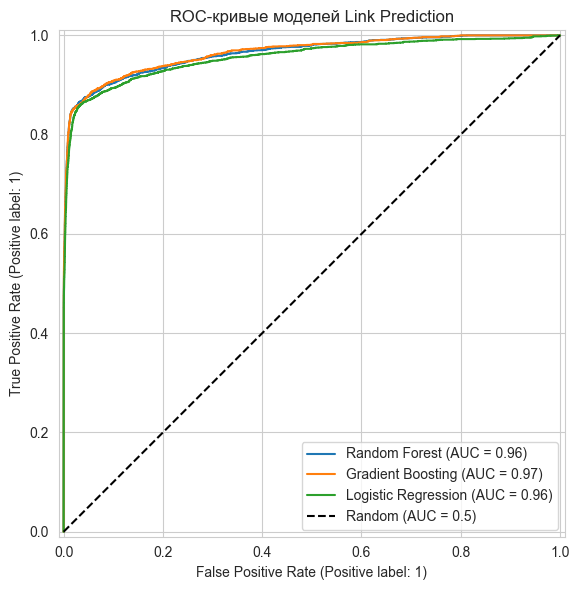

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

RocCurveDisplay.from_predictions(yTest, yProbaRF, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(yTest, yProbaGB, name="Gradient Boosting", ax=ax)
RocCurveDisplay.from_predictions(yTest, yProbaLR, name="Logistic Regression", ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
ax.set_title('ROC-кривые моделей Link Prediction')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

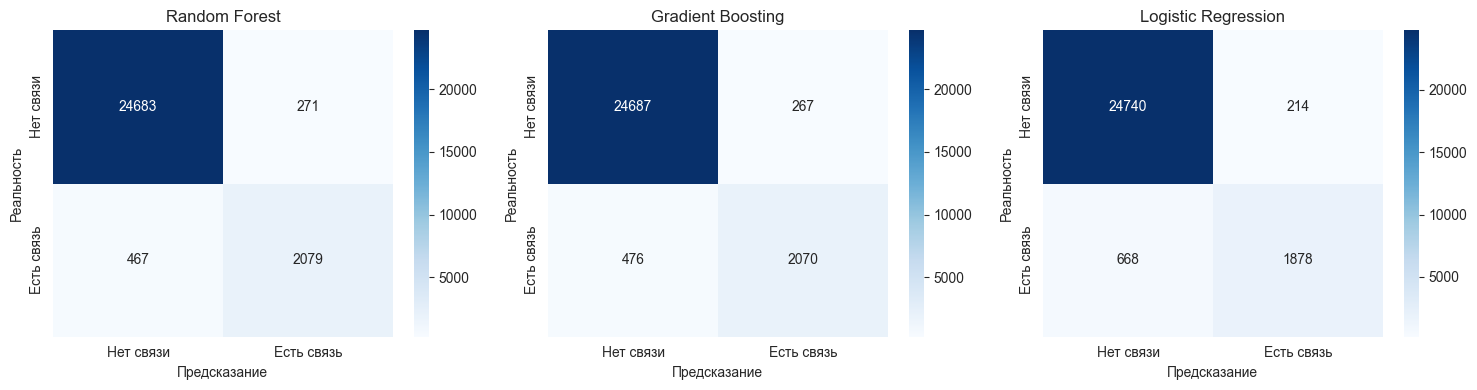

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, yPred, title in zip(axes, [yPredRF, yPredGB, yPredLR], ['Random Forest', 'Gradient Boosting', 'Logistic Regression']):
    cm = confusion_matrix(yTest, yPred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Нет связи', 'Есть связь'],
                yticklabels=['Нет связи', 'Есть связь'])
    ax.set_title(title)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Реальность')

plt.tight_layout()
plt.show()

 ## 5. Важность признаков

=== Важность признаков ===
         Признак  Важность (RF)  Важность (GB)  Важность (LR)
      adamicAdar       0.221554       0.251551       0.086611
 commonNeighbors       0.174919       0.014321       0.386739
         degree1       0.167047       0.260908       0.241659
    jaccardCoeff       0.146355       0.374849       0.019930
      degreeDiff       0.087018       0.007316       0.153700
  prefAttachment       0.083245       0.036405       0.032034
         degree2       0.039163       0.020108       0.042909
    jaccardGames       0.032916       0.015791       0.013768
   gameCountDiff       0.026924       0.009899       0.000770
commonGamesCount       0.020860       0.008852       0.021880


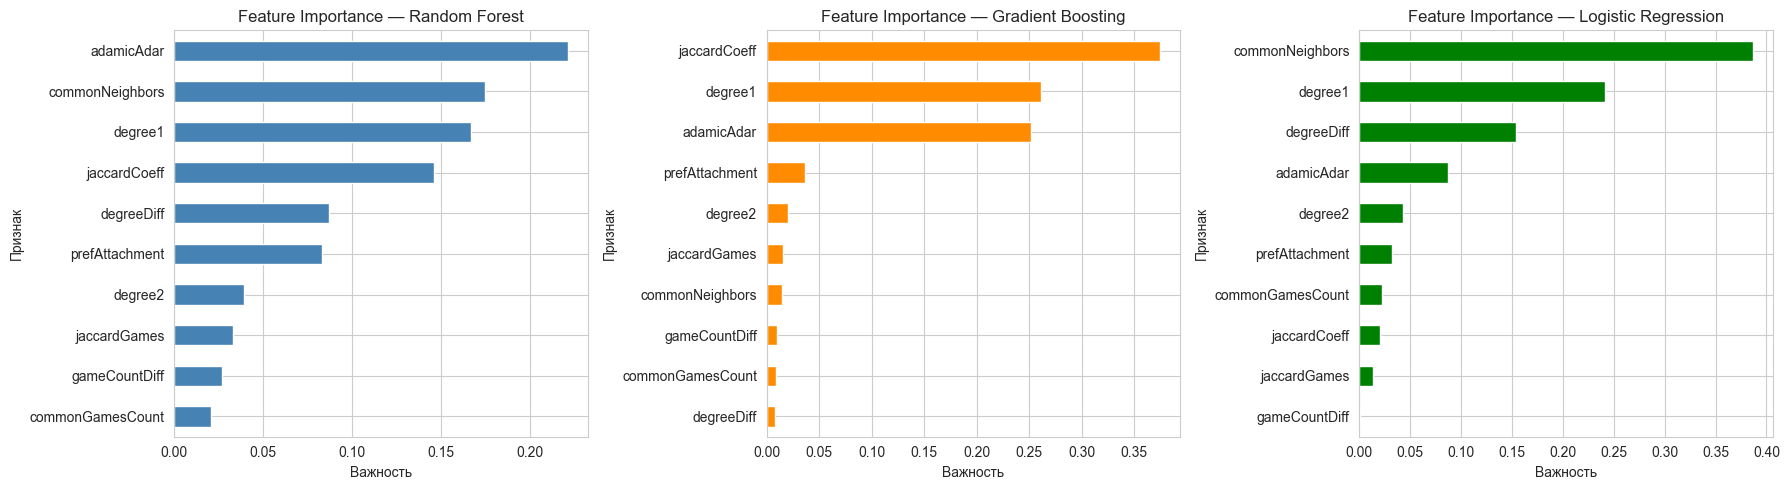

In [28]:
lrImportance = np.abs(lrModel.coef_[0])
lrImportance = lrImportance / lrImportance.sum()

featureImportance = pd.DataFrame({
    'Признак': featureColumns,
    'Важность (RF)': rfModel.feature_importances_,
    'Важность (GB)': gbModel.feature_importances_,
    'Важность (LR)': lrImportance
}).sort_values('Важность (RF)', ascending=False)

print("=== Важность признаков ===")
print(featureImportance.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

featureImportance.sort_values('Важность (RF)', ascending=True).plot.barh(
    x='Признак', y='Важность (RF)', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Важность')

featureImportance.sort_values('Важность (GB)', ascending=True).plot.barh(
    x='Признак', y='Важность (GB)', ax=axes[1], color='darkorange', legend=False
)
axes[1].set_title('Feature Importance — Gradient Boosting')
axes[1].set_xlabel('Важность')

featureImportance.sort_values('Важность (LR)', ascending=True).plot.barh(
    x='Признак', y='Важность (LR)', ax=axes[2], color='green', legend=False
)
axes[2].set_title('Feature Importance — Logistic Regression')
axes[2].set_xlabel('Важность')

plt.tight_layout()
plt.show()

 ## 6. Рекомендация друзей

In [30]:
def recommendFriends(targetUserId: str, G: nx.Graph, partition: dict,
                      userDataMap: dict, model, topN: int = 10,
                      featureScaler=None) -> pd.DataFrame:
    
    if targetUserId not in G:
        print(f"Пользователь {targetUserId} не найден в графе")
        return pd.DataFrame()

    currentFriends = set(G.neighbors(targetUserId))
    targetCommunity = partition.get(targetUserId, -1)
    
    # Кандидаты: пользователи из того же сообщества + пользователи, у которых есть общие друзья с целевым
    friendsOfFriends = set()
    for friend in currentFriends:
        for fof in G.neighbors(friend):
            if fof != targetUserId and fof not in currentFriends:
                friendsOfFriends.add(fof)
    
    sameCommNodes = set(n for n, c in partition.items() if c == targetCommunity)
    sameCommNodes.discard(targetUserId)
    sameCommNodes -= currentFriends
    
    candidates = list(friendsOfFriends | sameCommNodes)
    
    if len(candidates) > 500:
        candidates = random.sample(candidates, 500)
    
    predictions = []
    for candidate in candidates:
        features = computeLinkFeatures(G, targetUserId, candidate, partition, userDataMap)
        featureVector = np.array([[features[col] for col in featureColumns]])
        
        if featureScaler is not None:
            featureVector = featureScaler.transform(featureVector)
        
        probability = model.predict_proba(featureVector)[0][1]
        
        predictions.append({
            'candidateId': candidate,
            'probability': probability,
            'commonNeighbors': features['commonNeighbors'],
            'commonGames': features['commonGamesCount'],
            'sameCommunity': features['sameCommunity'],
            'jaccardGames': features['jaccardGames']
        })
    
    predictionsDF = pd.DataFrame(predictions)
    predictionsDF = predictionsDF.sort_values('probability', ascending=False).head(topN)
    predictionsDF = predictionsDF.reset_index(drop=True)
    predictionsDF.index += 1
    
    return predictionsDF


nodesWithFriends = [n for n in GLargest.nodes() if GLargest.degree(n) >= 5]
if nodesWithFriends:
    demoUser = random.choice(nodesWithFriends)
    print(f"Пользователь: {demoUser}")
    print(f"Текущих друзей: {GLargest.degree(demoUser)}")
    print(f"Сообщество: {partition.get(demoUser)}")
    
    for modelName, model, modelScaler in [('Random Forest', rfModel, None), ('Gradient Boosting', gbModel, None), ('Logistic Regression', lrModel, scaler)]:
        print(f"\nТоп-10 рекомендованных друзей ({modelName}):")
        
        recommendations = recommendFriends(
            targetUserId=demoUser,
            G=GLargest,
            partition=partition,
            userDataMap=userDataMap,
            model=model,
            topN=10,
            featureScaler=modelScaler
        )
        print(recommendations.to_string())
else:
    print("Недостаточно данных для демонстрации")

Пользователь: 76561198344519733
Текущих друзей: 10
Сообщество: 88

Топ-10 рекомендованных друзей (Random Forest):
          candidateId  probability  commonNeighbors  commonGames  sameCommunity  jaccardGames
1   76561199236544413     0.999966                3            2              1      0.090909
2   76561199078590793     0.999966                2            7              1      0.120690
3   76561199079003565     0.999948                2            3              1      0.120000
4   76561198365351032     0.996216                2            7              1      0.095890
5   76561198387468435     0.992827                1            6              0      0.098361
6   76561198255619051     0.990608                1            8              0      0.190476
7   76561198971265954     0.985075                1            3              1      0.066667
8   76561198797088177     0.985075                1            4              0      0.075472
9   76561199489640612     0.983018      